# M2R : Takens Delay Embedding + Persistent Homology via Gudhi
-------------------------------------------------------
Pipeline:
  1. Generate an artificial time series (noisy sine wave)
  2. Construct the Takens delay embedding → point cloud in R^d
  3. Compute persistent homology (Vietoris–Rips) using Gudhi
  4. Plot: time series | point cloud | persistence diagram | barcode

Install dependencies (run once in your notebook):
    import sys
    !{sys.executable} -m pip install gudhi numpy matplotlib scikit-learn
"""

In [1]:
import sys
# !{sys.executable} -m pip install gudhi numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gudhi

import matplotlib
matplotlib.use("inline")

# ─────────────────────────────────────────────────────────────────────────────
# 1. ARTIFICIAL TIME SERIES
#    A noisy sine wave — the underlying loop in its attractor means H1
#    (1-dimensional holes / loops) should show a prominent persistent bar.
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
np.random.seed(42)

N      = 600                          # number of time steps
t      = np.linspace(0, 6 * np.pi, N)
signal = np.sin(t) + 0.15 * np.random.randn(N)   # sine + small noise

In [4]:
print(type(signal))
print(signal.shape)

<class 'numpy.ndarray'>
(600,)


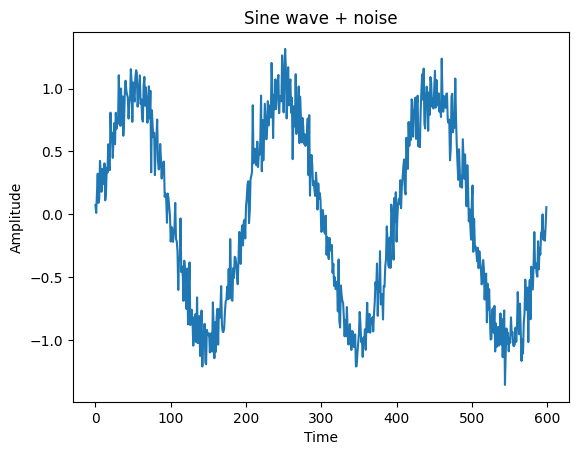

In [5]:
# plot graph of the signal
t_vals = np.arange(0,signal.shape[0])
plt.plot(t_vals, signal)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sine wave + noise')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 2. TAKENS DELAY EMBEDDING
#
#    Given a scalar time series  x(0), x(1), …, x(N-1)
#    and parameters:
#      d   = embedding dimension  (number of coordinates per point)
#      tau = time delay           (gap between successive coordinates)
#
#    Each embedded point is:
#      p_i = [ x(i), x(i + tau), x(i + 2*tau), …, x(i + (d-1)*tau) ]
#
#    The result is a point cloud of shape  (N - (d-1)*tau)  ×  d
# ─────────────────────────────────────────────────────────────────────────────

In [6]:
def takens_embedding(series : np.ndarray,
                     d : int,
                     tau : int
                     ) -> np.ndarray:
    """
    Parameters
    ----------
    series : 1-D array, length N
    d      : embedding dimension
    tau    : time delay (integer, in samples)

    Returns
    -------
    cloud : ndarray of shape (N - (d-1)*tau, d)
    """
    N = len(series)
    M = N - (d - 1) * tau          # number of embedded points
    cloud = np.empty((M, d))
    for k in range(d):
        cloud[:, k] = series[k * tau : k * tau + M]
    return cloud

In [7]:
d   = 2      # 2-D embedding so we can visualise the loop directly
tau = 15     # lag chosen to be ~quarter-period of the sine wave

point_cloud = takens_embedding(signal, d=d, tau=tau)

print(f"Time series length : {N}")
print(f"Embedding (d={d}, tau={tau}) → point cloud shape: {point_cloud.shape}")

Time series length : 600
Embedding (d=2, tau=15) → point cloud shape: (585, 2)


# ─────────────────────────────────────────────────────────────────────────────
# 3. PERSISTENT HOMOLOGY via Gudhi  (Vietoris–Rips filtration)
#
#    Gudhi builds a Rips complex by growing balls of radius $\epsilon$ around each
#    point and recording when simplices (edges, triangles, …) appear.
#    Persistent homology tracks:
#      H0 — connected components  (points merging into clusters)
#      H1 — loops / 1-cycles      (the sine attractor loop appears here)
# ─────────────────────────────────────────────────────────────────────────────

In [8]:
MAX_EDGE_LENGTH = 1.5     # maximum ε to consider (tune if your cloud is rescaled)
MAX_DIM         = 2       # compute H0 and H1  (HomDim = MAX_DIM - 1)

rips = gudhi.RipsComplex(
    points          = point_cloud,
    max_edge_length = MAX_EDGE_LENGTH,
)

In [9]:
simplex_tree = rips.create_simplex_tree(max_dimension=MAX_DIM)
simplex_tree.compute_persistence()

persistence = simplex_tree.persistence()   # list of (dimension, (birth, death)) tuples

In [10]:
print(type(persistence))
print(len(persistence))

<class 'list'>
718


In [11]:
# print it all out explicitly
count =0
for dim, (birth, death) in persistence:
    print(count, dim, birth, death)
    count +=1

0 1 0.11718208024317193 0.23273342455349322
1 1 0.16655487174786782 0.2670507619419306
2 1 0.13981934439262286 0.2320184891423077
3 1 0.0887442430198064 0.17511588312431423
4 1 0.1576453469010578 0.2341425530018885
5 1 0.14279792730867055 0.2157275556987421
6 1 0.19497333077001183 0.26610296643203224
7 1 0.0936912354971742 0.16315921441623765
8 1 0.06741961711600665 0.12654661631579203
9 1 0.16636497510617076 0.22104183048019838
10 1 0.12705606701456373 0.17923385695172211
11 1 0.08233107512781826 0.13217263468237792
12 1 0.07723889393530232 0.1254024442330812
13 1 0.07450323009264477 0.11825784599663958
14 1 0.16159037084417757 0.2039249747835016
15 1 0.11740068417901935 0.15919699185259117
16 1 0.06660293157601704 0.10757286644017963
17 1 0.0965486494457197 0.13628925219190285
18 1 0.10010120467839119 0.1397483073263933
19 1 0.06081153108627549 0.09900031193000325
20 1 0.07872711639233379 0.11648081504151726
21 1 0.20921817662096023 0.2457282227865466
22 1 0.09797316960117927 0.13230

In [12]:
# Separate by homology dimension
def get_pairs(persistence : list,
              dim : int
              ) -> tuple:

    pairs = [(b, d) for (dim_, (b, d)) in persistence
             if dim_ == dim and d != float("inf")]
    inf_  = [(b, d) for (dim_, (b, d)) in persistence
             if dim_ == dim and d == float("inf")]
    return pairs, inf_

In [13]:
h0_pairs, h0_inf = get_pairs(persistence, 0)
h1_pairs, h1_inf = get_pairs(persistence, 1)

print(f"\nH0 (components) : {len(h0_pairs)} finite bars + {len(h0_inf)} infinite")
print(f"H1 (loops)      : {len(h1_pairs)} finite bars + {len(h1_inf)} infinite")


H0 (components) : 584 finite bars + 1 infinite
H1 (loops)      : 133 finite bars + 0 infinite


In [14]:
if h1_pairs:
    lifetimes = [(d - b, b, d) for b, d in h1_pairs]
    lifetimes.sort(reverse=True)
    print(f"\nTop 3 H1 bars (birth → death, lifetime):")
    for life, b, d in lifetimes[:3]:
        print(f"  birth={b:.3f}  death={d:.3f}  lifetime={life:.3f}")


Top 3 H1 bars (birth → death, lifetime):
  birth=0.117  death=0.233  lifetime=0.116
  birth=0.167  death=0.267  lifetime=0.100
  birth=0.140  death=0.232  lifetime=0.092


# ─────────────────────────────────────────────────────────────────────────────
# 4. PLOTS
# ─────────────────────────────────────────────────────────────────────────────

In [15]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)
COLOURS = {0: "red", 1 : "blue", 2 : "green"}
#COLORS = {0: "#2563EB", 1: "#DC2626", 2: "#16A34A"}

<Figure size 1400x1000 with 0 Axes>

# ── (a) Time series ───────────────────────────────────────────────────────────

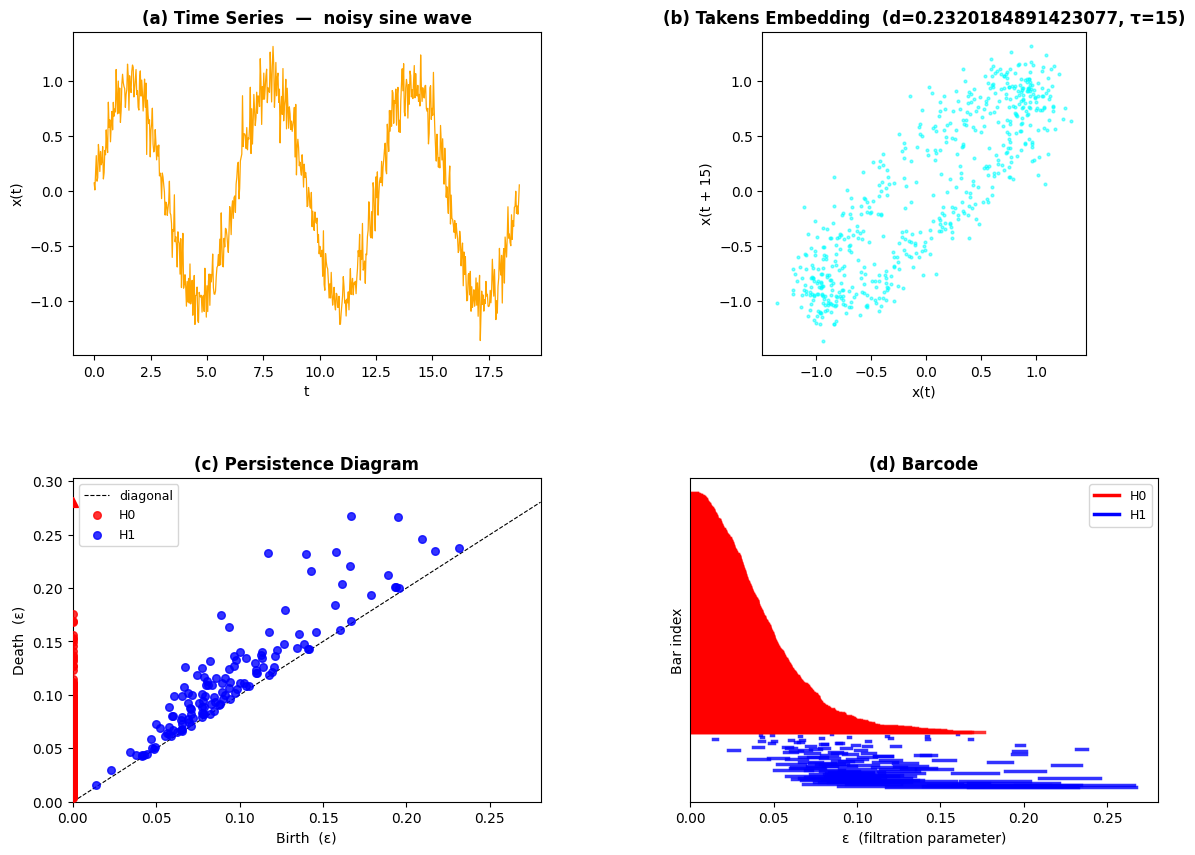

Done ✓


In [16]:
# ── (a) Time series ───────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t, signal, linewidth=0.9, color="orange")
ax0.set_title("(a) Time Series  —  noisy sine wave", fontweight="bold")
ax0.set_xlabel("t")
ax0.set_ylabel("x(t)")

# ── (b) Takens point cloud ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(point_cloud[:, 0], point_cloud[:, 1],
            s=4, alpha=0.5, color="cyan")
d_sixdp = (int(d * 10**6))/10**6
ax1.set_title(f"(b) Takens Embedding  (d={d}, τ={tau})", fontweight="bold")
ax1.set_xlabel("x(t)")
ax1.set_ylabel(f"x(t + {tau})")
ax1.set_aspect("equal")

# ── (c) Persistence diagram ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

all_finite = h0_pairs + h1_pairs
if all_finite:
    max_val = max(d for _, d in all_finite) * 1.05
else:
    max_val = MAX_EDGE_LENGTH

ax2.plot([0, max_val], [0, max_val], "k--", linewidth=0.8, label="diagonal")

for dim, pairs in [(0, h0_pairs), (1, h1_pairs)]:
    if pairs:
        births, deaths = zip(*pairs)
        ax2.scatter(births, deaths, s=30, alpha=0.8,
                    color=COLOURS[dim], label=f"H{dim}", zorder=3)

# Infinite bars plotted just above the max
for dim, inf_bars in [(0, h0_inf), (1, h1_inf)]:
    for (b, _) in inf_bars:
        ax2.scatter(b, max_val, marker="^", s=50,
                    color=COLOURS[dim], zorder=3)

ax2.set_xlim(0, max_val)
ax2.set_ylim(0, max_val * 1.08)
ax2.set_title("(c) Persistence Diagram", fontweight="bold")
ax2.set_xlabel("Birth  (ε)")
ax2.set_ylabel("Death  (ε)")
ax2.legend(fontsize=9)

# ── (d) Barcode ───────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

bars_to_plot = []
for dim, pairs in [(0, h0_pairs), (1, h1_pairs)]:
    for b, d in pairs:
        bars_to_plot.append((dim, b, d, d - b))

# Sort by dimension then lifetime descending
bars_to_plot.sort(key=lambda x: (-x[0], -(x[3])))

for i, (dim, b, d, _) in enumerate(bars_to_plot):
    ax3.plot([b, d], [i, i], linewidth=2.5,
             color=COLOURS[dim], alpha=0.8,
             label=f"H{dim}" if i == next(
                 (j for j, (dd, *_) in enumerate(bars_to_plot) if dd == dim), None
             ) else "")

# Legend (deduplicated)
handles = [plt.Line2D([0], [0], color=COLOURS[d], linewidth=2.5, label=f"H{d}")
           for d in sorted(COLOURS) if d <= 1]
ax3.legend(handles=handles, fontsize=9)
ax3.set_title("(d) Barcode", fontweight="bold")
ax3.set_xlabel("ε  (filtration parameter)")
ax3.set_ylabel("Bar index")
ax3.set_xlim(0, max_val)
ax3.set_yticks([])

plt.suptitle(
    "Takens Embedding + Persistent Homology (Vietoris–Rips)\n"
    "Noisy sine wave  →  loop detected in H₁",
    fontsize=12, fontweight="bold", y=1.01,
)

#plt.savefig("takens_persistent_homology.png", dpi=150, bbox_inches="tight")
#plt.show()
display(fig)
plt.close()
#print("\nFigure saved → takens_persistent_homology.png")
print("Done ✓")